# Citation
Refer to Li et al., Arxiv, 2024. Dynamics of Adaptive Continuous Attractor Neural Networks.
https://doi.org/10.48550/arXiv.2410.06517

And https://github.com/Routhleck/canns

<SmoothTracking1D> Generating Task data: 200it [00:00, 5496.62it/s]
Running for 200 iterations: 100%|██████████| 200/200 [00:00<00:00, 103460.88it/s]


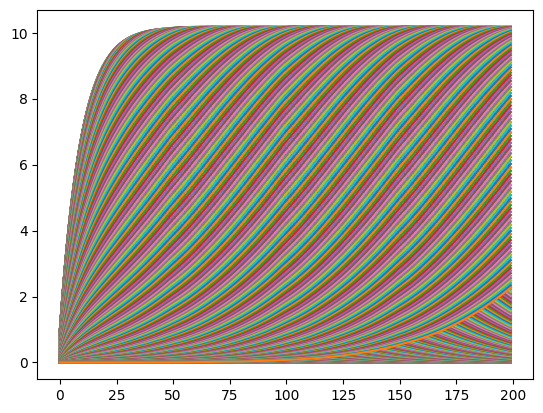

In [5]:
import brainstate
from canns.models.basic import CANN1D
from canns.task.tracking import SmoothTracking1D

brainstate.environ.set(dt=0.1)

cann = CANN1D(num=512)
cann.init_state()

task = SmoothTracking1D(
    cann_instance=cann,
    Iext=(0.0, 0.5, 1.0, 1.5, 2.0),
    duration=(5.0, 5.0, 5.0, 5.0),
    time_step=brainstate.environ.get_dt(),
)
task.get_data()

def step(t, stimulus):
    cann(stimulus)
    return cann.u.value, cann.inp.value

us, inputs = brainstate.compile.for_loop(
    step,
    task.run_steps,
    task.data,
    pbar=brainstate.compile.ProgressBar(10),
)

import matplotlib.pyplot as plt
plt.plot(us)
plt.show()